# Dessert

- Dessert depends on Plaid artifacts
- run Plaid build first
- Dessert uses the Plaid centroids and codes

| 论文符号 | 底层代码中的变量名 | 传入方式 | 底层代码逻辑 |
| :--- | :--- | :--- | :--- |
| **\( L \)**（哈希表数量） | `num_tables` | `build_index` 直接传入 | 控制 `dessert_py.DocRetrieval` 的 `num_tables` |
| **\( C \)**（拼接哈希数） | `hashes_per_table` | `build_index` 传入，**有默认值 `-1`** | 若 `-1`，自动计算为 `int(np.ceil(np.log2(np.average(doclens))))`。即 **`C = ceil(log2(平均文档向量数))`** |
| **filter_k**（精排候选数） | `initial_filter_k` | `retrieval_config_l` 传入 | 传给 `index.query(..., num_to_rerank=initial_filter_k, ...)` |
| **filter_probe**（探测聚类数） | `nprobe_query` | `retrieval_config_l` 传入 | 用于 `torch.topk(..., nprobe_query)`，控制预过滤宽度 |

---

In [1]:
# plot

%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_qps_metrics(csv_file, topk=None, retrieval_nprobe_query=None, retrieval_initial_filter_k_list=None):
    """
    DESSERT
    绘制 QPS vs Recall@100 和 QPS vs MRR@100 曲线。
    
    参数:
        csv_file (str): CSV 文件路径。
        topk (int, optional): 只绘制指定 topk 的结果（如 100）。
        retrieval_initial_filter_k_list (list, optional): 只绘制 retrieval_initial_filter_k 在列表中的行。
    """
    # 读取数据
    df = pd.read_csv(csv_file)

    # 过滤 topk
    if topk is not None:
        df = df[df['topk'] == topk]

    # 过滤 topk
    if retrieval_nprobe_query is not None:
        df = df[df['retrieval_nprobe_query'] == retrieval_nprobe_query]
    
    # 过滤 retrieval_initial_filter_k
    if retrieval_initial_filter_k_list is not None:
        df = df[df['retrieval_initial_filter_k'].isin(retrieval_initial_filter_k_list)]
    
    # 如果过滤后为空，给出提示
    if df.empty:
        print("筛选后没有数据，请检查参数。")
        return
    
    # 按 QPS 升序排序，使曲线连贯
    df_sorted = df.sort_values("qps")
    
    # 设置绘图风格
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['font.size'] = 12
    
    # 创建两个子图，方便比较
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # ---------- 图1: QPS vs Recall@100 ----------
    ax1.plot(df_sorted["qps"], df_sorted["recall@100"], 
             marker='o', linestyle='-', linewidth=2, markersize=8, color='b')
    ax1.set_xlabel("QPS (queries/sec)", fontsize=14)
    ax1.set_ylabel("Recall@100", fontsize=14)
    ax1.set_title("QPS vs Recall@100", fontsize=16)
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # 标注每个点：优先使用 'retrieval_initial_filter_k' 列，若无则用行号
    if 'retrieval_initial_filter_k' in df_sorted.columns:
        label_col = 'retrieval_initial_filter_k'
        label_prefix = 'k='
    else:
        label_col = None
        label_prefix = ''
    
    for idx, row in df_sorted.iterrows():
        if label_col:
            label = f"{label_prefix}{row[label_col]}"
        else:
            label = f"idx{idx}"
        ax1.annotate(label, 
                     xy=(row["qps"], row["recall@100"]),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    # ---------- 图2: QPS vs MRR@100 ----------
    ax2.plot(df_sorted["qps"], df_sorted["mrr@100"], 
             marker='s', linestyle='-', linewidth=2, markersize=8, color='r')
    ax2.set_xlabel("QPS (queries/sec)", fontsize=14)
    ax2.set_ylabel("MRR@100", fontsize=14)
    ax2.set_title("QPS vs MRR@100", fontsize=16)
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    for idx, row in df_sorted.iterrows():
        if label_col:
            label = f"{label_prefix}{row[label_col]}"
        else:
            label = f"idx{idx}"
        ax2.annotate(label, 
                     xy=(row["qps"], row["mrr@100"]),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)

    ax1.set_xscale('log')
    ax2.set_xscale('log')
    ax1.set_xticks([1, 10, 100, 1000])
    ax1.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$'])
    ax2.set_xticks([1, 10, 100, 1000])
    ax2.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$'])
    
    plt.tight_layout()
    
    # 保存到 CSV 同目录，文件名与 CSV 相同（扩展名 .png）
    output_dir = os.path.dirname(csv_file)
    base_name = os.path.splitext(os.path.basename(csv_file))[0]
    save_path = os.path.join(output_dir, base_name + ".png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"图片已保存为 '{save_path}'")

# [100, 200, 500, 1000, 2000, 5000, 8000, 10000]
# 2 4

In [1]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_qps_grouped(
    csv_file,
    topk=100,
    metric='recall@100',              # 可选 'recall@100' 或 'mrr@100'
    filter_n_table=None,              # 例如 [64, 128, 512] 或 None（全部）
    filter_nprobe=None,               # 例如 [2, 4, 8] 或 None（全部）
    filter_initial_k=None,            # 例如 [512, 1024, 4096] 或 None（全部）
    group_by=['build_n_table', 'retrieval_nprobe_query'],
    figsize=(12, 8),
    save_plot=True,
    xscale='log',
    ylim=None,
    show_annotation=False,            # 是否在每个点上标注 initial_filter_k 值
):
    """
    绘制 QPS vs 指定指标 的帕累托曲线，按 (n_table, nprobe) 分组。
    颜色方案根据曲线数量自动选择：≤10 用 tab10，≤20 用 tab20，更多用 gist_ncar。
    """
    # 读取数据
    df = pd.read_csv(csv_file)
    
    # 过滤 topk
    if topk is not None:
        df = df[df['topk'] == topk]
    
    # 过滤 n_table
    if filter_n_table is not None:
        df = df[df['build_n_table'].isin(filter_n_table)]
    
    # 过滤 nprobe
    if filter_nprobe is not None:
        df = df[df['retrieval_nprobe_query'].isin(filter_nprobe)]
    
    # 过滤 initial_filter_k
    if filter_initial_k is not None:
        df = df[df['retrieval_initial_filter_k'].isin(filter_initial_k)]
    
    if df.empty:
        print("筛选后没有数据，请调整过滤条件。")
        return
    
    # 按分组列创建组合标签
    df['group_label'] = df[group_by].astype(str).agg('_'.join, axis=1)
    
    # 获取所有唯一分组（按 n_table 排序使颜色连续）
    groups = sorted(df['group_label'].unique(), 
                    key=lambda x: (int(x.split('_')[0]), int(x.split('_')[1])))
    
    # ------- 颜色选择（参考 plot_hnsw_combinations） -------
    n_curves = len(groups)
    if n_curves <= 10:
        cmap = plt.cm.tab10
    elif n_curves <= 20:
        cmap = plt.cm.tab20
    else:
        cmap = plt.cm.gist_ncar   # 提供大量不同颜色
    colors = [cmap(i / n_curves) for i in range(n_curves)]
    # -----------------------------------------------------
    
    # 创建图形
    fig, ax = plt.subplots(figsize=figsize)
    
    for idx, group in enumerate(groups):
        # 提取该组数据
        group_df = df[df['group_label'] == group]
        group_df = group_df.sort_values('qps')
        
        parts = group.split('_')
        n_table = parts[0]
        nprobe = parts[1] if len(parts) > 1 else ''
        label = f"L={n_table}, probe={nprobe}"
        
        # 绘制折线
        ax.plot(group_df['qps'], group_df[metric],
                marker='o', linestyle='-', linewidth=2,
                markersize=6, color=colors[idx],
                label=label)
        
        # 可选：在点上标注 initial_filter_k
        if show_annotation:
            for _, row in group_df.iterrows():
                ax.annotate(f"k={int(row['retrieval_initial_filter_k'])}",
                            xy=(row['qps'], row[metric]),
                            xytext=(5, 5), textcoords='offset points',
                            fontsize=8, color=colors[idx])
    
    # 坐标轴与样式
    ax.set_xlabel("QPS (queries/sec)", fontsize=14)
    ax.set_ylabel(metric.replace('@', ' @ ').upper(), fontsize=14)
    ax.set_title(f"Pareto Frontier: QPS vs {metric} (top-{topk})", fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    if xscale == 'log':
        ax.set_xscale('log')
        ax.set_xticks([1, 10, 100, 1000, 10000])
        ax.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$', '$10^4$'])
    
    if ylim is not None:
        ax.set_ylim(ylim)
    
    # 图例放在右侧外面，避免遮挡
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
    
    plt.tight_layout()
    
    if save_plot:
        output_dir = os.path.dirname(csv_file)
        base_name = os.path.splitext(os.path.basename(csv_file))[0]
        save_path = os.path.join(output_dir, f"{base_name}_grouped_{metric}.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图片已保存至: {save_path}")
    
    plt.show()
    return fig, ax

## Scidocs-large(1024 dim)

In [ ]:
# Run Dessert retrieval

python script/evaluation/eval_dessert.py \
  --username chenyifeng \
  --dataset scidocs-large-multi-flat-test

In [ ]:
# Evaluate Dessert results against local ground truth

python script/flat_multivector/eval_flat_groundtruth.py \
  --username chenyifeng \
  --dataset scidocs-large-multi-flat-test \
  --method dessert

In [ ]:
# plot

plot_qps_metrics("/path/to/your/new_file.csv")

## Scidocs

默认 未知

search thread 可调

In [ ]:
# Run One wrapper

bash script/flat_multivector/run_dessert_flat.sh chenyifeng scidocs

In [ ]:
100: {
        'n_table': [4, 8,16,32,64, 128, 256, 512],
        'initial_filter_k': [100, 128, 256, 512, 1024, 2048, 4096, 8192], 
        'nprobe_query': [1, 2, 4, 8, 16, 32],             
        'remove_centroid_dupes': [True],
        'n_thread': [1],
    },

图片已保存至: /data1/chenyifeng/Dataset/multi-vector-retrieval/Result/performance/dessert-scidocs-flat-eval-summary_grouped_recall@100.png


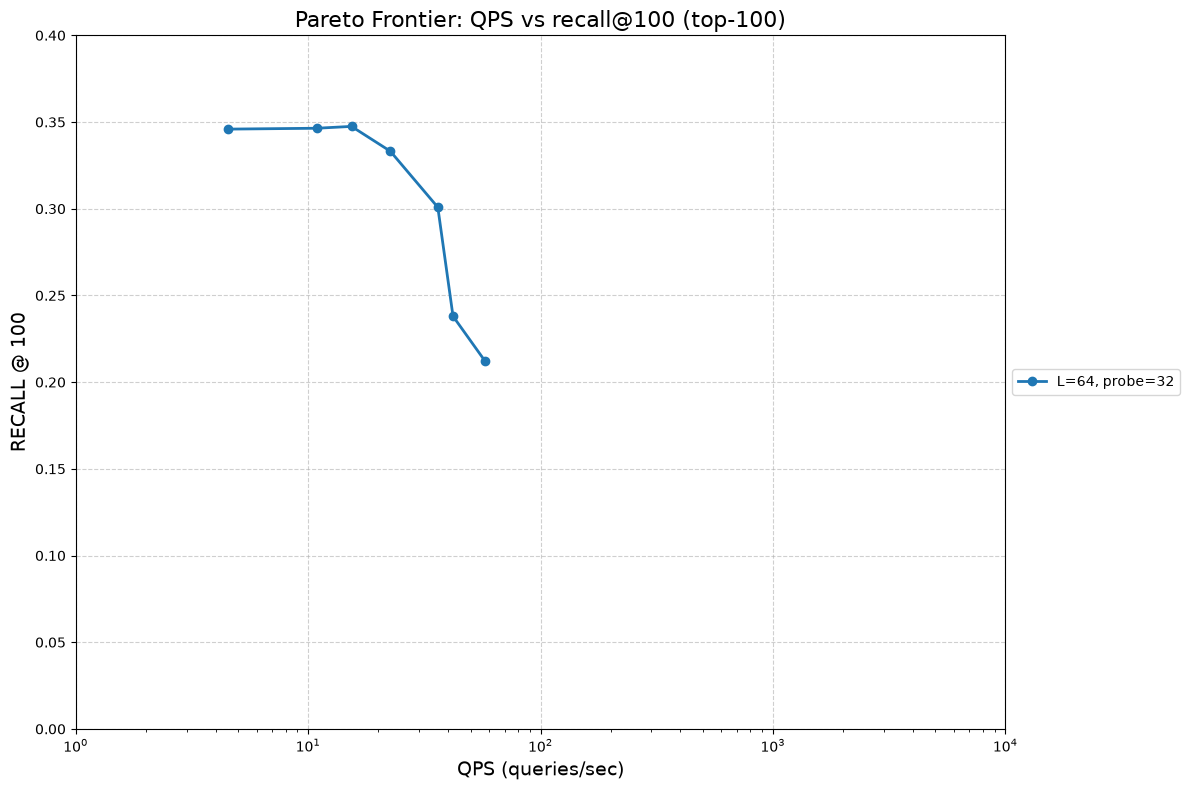

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Pareto Frontier: QPS vs recall@100 (top-100)'}, xlabel='QPS (queries/sec)', ylabel='RECALL @ 100'>)

In [25]:
plot_qps_grouped(
    csv_file="/data1/chenyifeng/Dataset/multi-vector-retrieval/Result/performance/dessert-scidocs-flat-eval-summary.csv",
    topk=100,
    metric='recall@100',
    filter_n_table=[64],
    filter_nprobe=[32],
    filter_initial_k=[100, 128, 256, 512, 1024, 2048, 4096],
    xscale='log',
    ylim=(0, 0.4)
)

# 

## Fiqa

In [ ]:
# Run One wrapper

bash script/flat_multivector/run_dessert_flat.sh chenyifeng fiqa

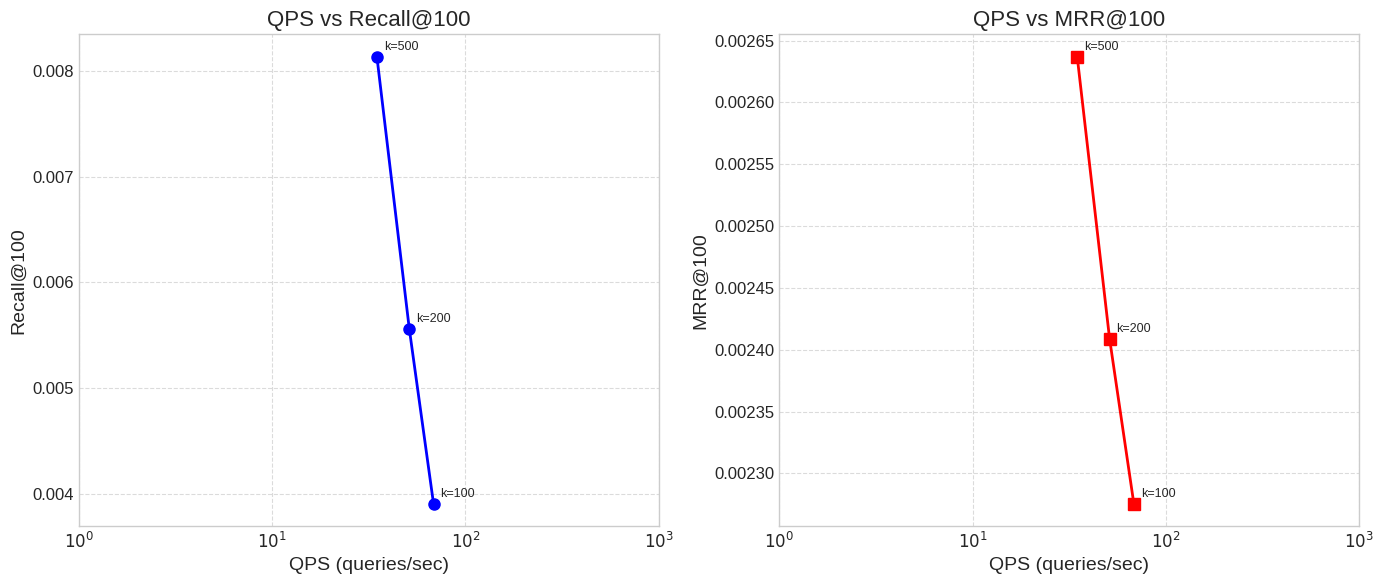

图片已保存为 '/data1/chenyifeng/Dataset/multi-vector-retrieval/Result/performance/dessert-fiqa-flat-eval-summary.png'


In [5]:
# plot

plot_qps_metrics("/data1/chenyifeng/Dataset/multi-vector-retrieval/Result/performance/dessert-fiqa-flat-eval-summary.csv",
                 topk=100,
                 retrieval_nprobe_query=4,
                 retrieval_initial_filter_k_list=[100, 200, 500])